In [1]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split, Subset
import timm
import random
from tqdm import tqdm
from sklearn.metrics import accuracy_score
import time

In [2]:
device = torch.device("cpu")
print("Using device:", device)

Using device: cpu


In [3]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [4]:
DATA_PATH = "../data/FF_frames"

dataset = ImageFolder(DATA_PATH, transform=transform)

print("Classes:", dataset.classes)
print("Total images:", len(dataset))

Classes: ['fake', 'real']
Total images: 31310


In [5]:
import random
from torch.utils.data import Subset

fraction = 0.3

subset_size = int(len(dataset) * fraction)

indices = random.sample(range(len(dataset)), subset_size)

dataset_small = Subset(dataset, indices)

print("Subset size:", len(dataset_small))

Subset size: 9393


In [6]:
train_size = int(0.8 * len(dataset_small))
val_size = len(dataset_small) - train_size

train_dataset, val_dataset = random_split(dataset_small, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=0)

print("Train:", train_size)
print("Validation:", val_size)

Train: 7514
Validation: 1879


In [7]:
cnn = timm.create_model("resnet50", pretrained=True)
cnn.fc = nn.Identity()

for p in cnn.parameters():
    p.requires_grad = False

cnn = cnn.to(device)
cnn.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act1): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act1): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (drop_block): Identity()
      (act2): ReLU(inplace=True)
      (aa): Identity()
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     

In [8]:
vit = timm.create_model("vit_base_patch16_224", pretrained=True)
vit.head = nn.Identity()

for p in vit.parameters():
    p.requires_grad = False

vit = vit.to(device)
vit.eval()

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False

In [9]:
class HybridModel(nn.Module):

    def __init__(self, cnn, vit):
        super().__init__()

        self.cnn = cnn
        self.vit = vit

        self.classifier = nn.Sequential(
            nn.Linear(2048 + 768, 256),
            nn.ReLU(),
            nn.Linear(256,2)
        )

    def forward(self,x):

        with torch.no_grad():
            f1 = self.cnn(x)
            f2 = self.vit(x)

        fused = torch.cat((f1,f2),dim=1)

        out = self.classifier(fused)

        return out


model = HybridModel(cnn,vit).to(device)

In [10]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.classifier.parameters(),
    lr=1e-3
)

In [11]:
def train_epoch():

    model.train()

    total_loss = 0

    loop = tqdm(train_loader)

    for images,labels in loop:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs,labels)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

        loop.set_postfix(loss=loss.item())

    return total_loss / len(train_loader)

In [12]:
def validate():

    model.eval()

    preds = []
    gt = []

    with torch.no_grad():

        for images,labels in val_loader:

            images = images.to(device)

            outputs = model(images)

            p = torch.argmax(outputs,1).cpu().numpy()

            preds.extend(p)
            gt.extend(labels.numpy())

    acc = accuracy_score(gt,preds)

    return acc

In [13]:
EPOCHS = 5

best_acc = 0

for epoch in range(EPOCHS):

    print("\nEpoch",epoch+1)

    start = time.time()

    loss = train_epoch()

    acc = validate()

    print("Loss:",loss)
    print("Val Acc:",acc)
    print("Time:",(time.time()-start)/60,"minutes")

    if acc > best_acc:
        best_acc = acc
        torch.save(model.state_dict(),"small_cnn_vit_model.pth")
        print("Saved best model")


Epoch 1


100%|██████████| 940/940 [1:06:56<00:00,  4.27s/it, loss=0.265]


Loss: 0.5503034174600814
Val Acc: 0.7546567323044172
Time: 82.0415353099505 minutes
Saved best model

Epoch 2


100%|██████████| 940/940 [45:11<00:00,  2.88s/it, loss=0.283]  


Loss: 0.48780930697759417
Val Acc: 0.7711548696114955
Time: 50.661092297236124 minutes
Saved best model

Epoch 3


...

Loss: 0.46776382135266953
Val Acc: 0.7711548696114955
Time: 28.449148297309875 minutes

Epoch 4


100%|██████████| 940/940 [22:53<00:00,  1.46s/it, loss=0.634] 


Loss: 0.4579882042046557
Val Acc: 0.7732836615220862
Time: 28.38622273604075 minutes
Saved best model

Epoch 5


100%|██████████| 940/940 [22:56<00:00,  1.46s/it, loss=0.696] 


Loss: 0.44776369573033237
Val Acc: 0.7764768493879723
Time: 28.41205599705378 minutes
Saved best model


In [14]:
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
import matplotlib.pyplot as plt

model.eval()

preds = []
labels_all = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)

        outputs = model(images)

        predicted = torch.argmax(outputs,1).cpu().numpy()

        preds.extend(predicted)
        labels_all.extend(labels.numpy())

preds = np.array(preds)
labels_all = np.array(labels_all)

acc = accuracy_score(labels_all,preds)
prec = precision_score(labels_all,preds)
rec = recall_score(labels_all,preds)
f1 = f1_score(labels_all,preds)

print("\n===== MODEL PERFORMANCE =====")

print("Accuracy:",acc)
print("Precision:",prec)
print("Recall:",rec)
print("F1 Score:",f1)

print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(labels_all,preds,target_names=["fake","real"]))


===== MODEL PERFORMANCE =====
Accuracy: 0.7764768493879723
Precision: 0.9050894085281981
Recall: 0.6521308225966304
F1 Score: 0.7580645161290323

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

        fake       0.70      0.92      0.79       870
        real       0.91      0.65      0.76      1009

    accuracy                           0.78      1879
   macro avg       0.80      0.79      0.78      1879
weighted avg       0.81      0.78      0.77      1879



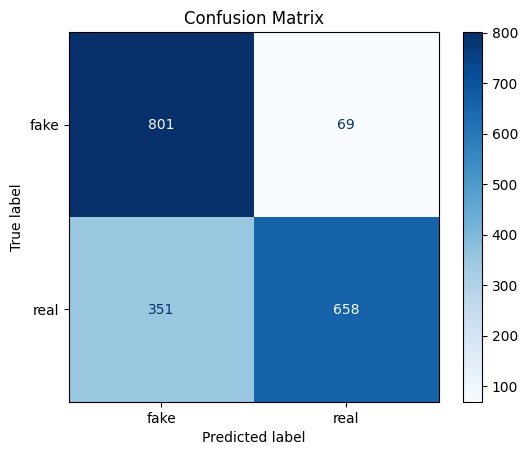

In [15]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(labels_all,preds)

disp = ConfusionMatrixDisplay(cm,display_labels=["fake","real"])

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")
plt.show()

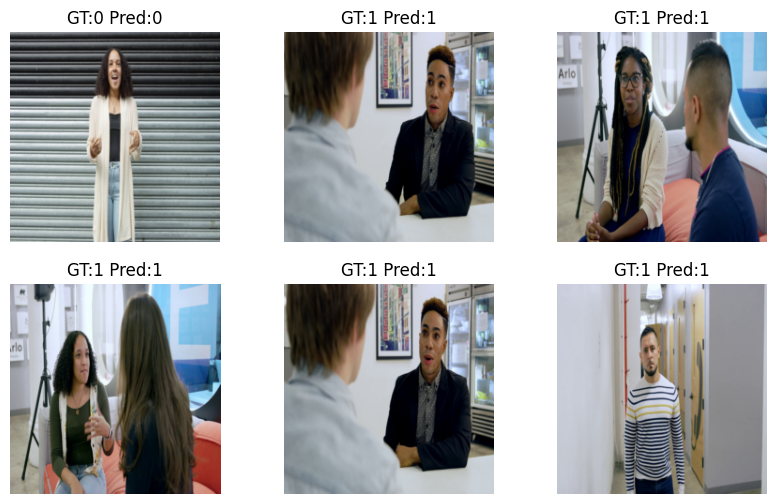

In [18]:
import matplotlib.pyplot as plt

model.eval()

images,labels = next(iter(val_loader))

with torch.no_grad():
    outputs = model(images.to(device))
    preds = torch.argmax(outputs,1).cpu()

fig = plt.figure(figsize=(10,6))

for i in range(6):

    ax = fig.add_subplot(2,3,i+1)

    img = images[i].permute(1,2,0)

    img = img * torch.tensor([0.229,0.224,0.225]) + torch.tensor([0.485,0.456,0.406])

    img = img.clamp(0,1)

    ax.imshow(img)

    ax.set_title(f"GT:{labels[i]} Pred:{preds[i]}")

    ax.axis("off")

plt.show()

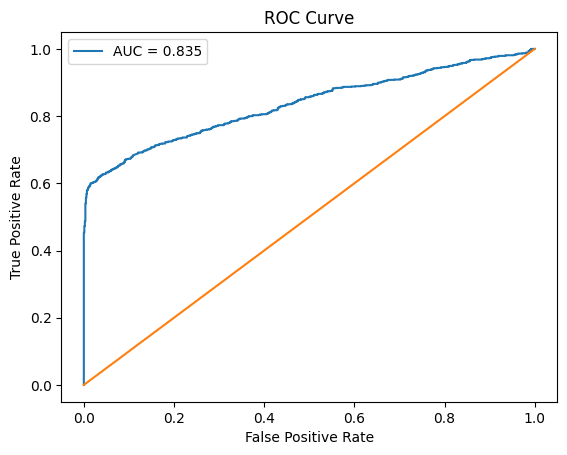

In [19]:
from sklearn.metrics import roc_curve, auc

probs = []

model.eval()

with torch.no_grad():

    for images,labels in val_loader:

        images = images.to(device)

        outputs = model(images)

        prob = torch.softmax(outputs,dim=1)[:,1].cpu().numpy()

        probs.extend(prob)

fpr,tpr,_ = roc_curve(labels_all,probs)

roc_auc = auc(fpr,tpr)

plt.plot(fpr,tpr,label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()